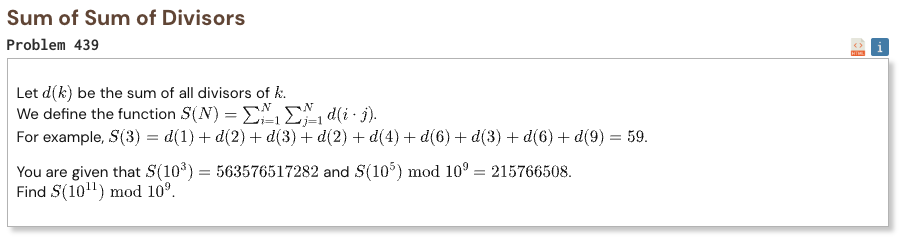

## Initial approach

-   rewrite the double divisor sum with the Möbius function so the two variables can be separated
-   define a prefix function for the sum of divisor sums up to a given limit
-   compute this divisor prefix efficiently by grouping values that have the same integer quotient
-   also need prefix sums of k times the Möbius value instead of calculating every k separately
-   use a sieve for smaller values and a memoized recursive formula for larger Möbius prefixes
-   group the main sum by equal values of N divided by k so only about square root many ranges are needed
-   keep all large calculations modulo 10 to the power 9 and evaluate the case N equals 10 to the power 11

In [1]:
%%time

import math
import sys

N = 10**11
MOD = 10**9

sys.setrecursionlimit(1_000_000)

sqrt_n = math.isqrt(N)
limit = min(int(N ** (2 / 3)), 3_000_000)
limit = max(limit, sqrt_n)

mu = [0] * (limit + 1)
composite = bytearray(limit + 1)
primes = []
mu[1] = 1

for i in range(2, limit + 1):
    if not composite[i]:
        primes.append(i)
        mu[i] = -1

    for p in primes:
        value = i * p

        if value > limit:
            break

        composite[value] = 1

        if i % p == 0:
            mu[value] = 0
            break

        mu[value] = -mu[i]

mu_prefix = [0] * (limit + 1)
total = 0

for i in range(1, limit + 1):
    total = (total + i * mu[i]) % MOD
    mu_prefix[i] = total

mu_cache = {}

def mobius_prefix(n):
    if n <= limit:
        return mu_prefix[n]

    if n in mu_cache:
        return mu_cache[n]

    result = 1
    left = 2

    while left <= n:
        q = n // left
        right = n // q
        interval_sum = (left + right) * (right - left + 1) // 2
        result -= interval_sum * mobius_prefix(q)
        result %= MOD
        left = right + 1

    mu_cache[n] = result
    return result

sigma = [0] * (sqrt_n + 1)

for d in range(1, sqrt_n + 1):
    for multiple in range(d, sqrt_n + 1, d):
        sigma[multiple] += d

sigma_prefix = [0] * (sqrt_n + 1)
total = 0

for i in range(1, sqrt_n + 1):
    total = (total + sigma[i]) % MOD
    sigma_prefix[i] = total

def divisor_prefix(n):
    if n <= sqrt_n:
        return sigma_prefix[n]

    result = 0
    left = 1

    while left <= n:
        q = n // left
        right = n // q
        interval_sum = (left + right) * (right - left + 1) // 2
        result += q * interval_sum
        result %= MOD
        left = right + 1

    return result

result = 0
left = 1

while left <= N:
    q = N // left
    right = N // q

    weight = (
        mobius_prefix(right)
        - mobius_prefix(left - 1)
    ) % MOD

    divisor_sum = divisor_prefix(q)

    result += weight * divisor_sum * divisor_sum
    result %= MOD

    left = right + 1

print("Result:", result)

Result: 968697378
CPU times: user 2min 8s, sys: 694 ms, total: 2min 8s
Wall time: 2min 10s
